# Linear Regression


![linear regression line](./images/linear_regression_line.png "linear_regression_line")

Linear Regression houdt, samenvattend, het volgende in:
1. Een rechte lijn aanpassen aan een dataset van waarnemingen
     > Minimaliseert de kwadratische fout tussen elk punt en de lijn y = m*x+b</br>

2. Deze lijn (Ml-model) gebruiken om te voorspellen.

3. Bepalen hoe *goed* het model is met behulp van statistische metrieken, zoals o.a. R<sup>2</sup> bij linear regression.
   
    > Waarde voor R<sup>2</sup> liggen in tussen 0 en 1: 0 = slecht, 1 = goed 
    > R<sup>2</sup> is ook bekend onder de naam **Pearson correlation coefficient**.


### Werkcollege onderwerpen:

#### Wat ga je doen?
Doorloop en voeruit (*Run* of *Shift+Enter*) de Python voorbeelden en doe de opdrachten. Kijk niet te snel in de voorbeeldoplossingen notebook, maar probeer het eerst zelf, of met teamgenoten.

- Setup: software engineering
> - Check de Python en library versies.
> - Helper functions - maken het leven makkelijker.
> - Configuraties voor betere grafieken.

- ML workflow
> - Data inlezen of genereren
> - Data verkennen, bij voorkeur visueel.
> - ML-model toepassen op de data: 2 regression modellen
> - ML-model valideren met statistische metrieken, zoals R<sup>2</sup>, RMSE en correlatieanalyse.
> - Het getrainde ML-model bewaren voor later gebruik.

- Opdrachten
> - linear regression, polynomial regression. multiple regression
> - validatie technieken
    > RMSE, R<sup>2</sup>, correlatieanalyse

- Datasets
> - random gegenereerde data
> - folder `data`: cars.xls

---
## Setup - software engineering

1. Requirements:
> Python >3.7</br>
> Scikit-Learn ≥ 1.0.1:

2. Plot configuratie: vergroot de labels om de figuren mooier te maken.

3. Maak een map `images/training_linear_models` (als deze nog niet bestaat) en definieer de functie `save_fig()` om de figuren in hoge resolutie op te slaan.

In [20]:
%matplotlib inline

import sys
from pathlib import Path
from packaging import version
import sklearn
import matplotlib.pyplot as plt

# Check Python and library versions
assert sys.version_info >= (3, 7)
# check scikit-learn version
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

# Increase font size for plots
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


# Create the `images/training_linear_models` folder
IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)


In [21]:
# show version numbers of libraries

# Python -> use platform and sys modules
import platform, sys
print(f"Python: {platform.platform()}, version: {sys.version[0:6]}")

# data science libraries
import numpy as np
import pandas as pd
import seaborn as sns
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")

# plotting library
import matplotlib as mp
print(f"matplotlib: {mp.__version__}")

# ML-models library
import sklearn as sk
print(f"scikit-learn: {sk.__version__}")

# statistics library
import statsmodels
print(f"statsmodels: {statsmodels.__version__}")

Python: Windows-10-10.0.26100-SP0, version: 3.11.9
numpy: 2.3.5
pandas: 2.3.3
seaborn: 0.13.2
matplotlib: 3.10.7
scikit-learn: 1.7.2
statsmodels: 0.14.5


---
## Voorbeeld eenvoudig linear regression probleem

Eenvoudige lineaire regressie omdat we met één (independend)variabele het model laten uitrekenen:

- genereer 100 willekeurige data, zijnde de independend data X.
- genereer de depended variable y volgens een lineare relatie met random data gesuperponeerd. 
  > Kortom, eigelijk weten we al wat de ML-model parameters zijn (richtingscoeffcient en interceptie).
- train de data
- bekijk de resultaten voor het ML-model

In [22]:
# generate data

np.random.seed(42)  # to make this code example reproducible
m = 1000  # number of instances
X = 2 * np.random.rand(m, 1)  # column vector
y = 4 + 3 * X + np.random.randn(m, 1)  # column vector

In [25]:
# ML model - using sklearn 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ML model: selection and train and results
lin_reg = LinearRegression()
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lin_reg.fit(X_train, y_train)  # train
lin_reg.intercept_, lin_reg.coef_    # results linear model

(array([4.18985729]), array([[2.91204789]]))

Dit betekent dat het ML model is:
y = 2.77011339*X + 4.21509616</br>
Hetgeen we ook hadden verwacht: y = 3*X + 4

In [26]:
# predict new values
X_new = np.array([[0], [2]])  # new, unknown X
y_predict = lin_reg.predict(X_new)
y_predict

array([[ 4.18985729],
       [10.01395308]])

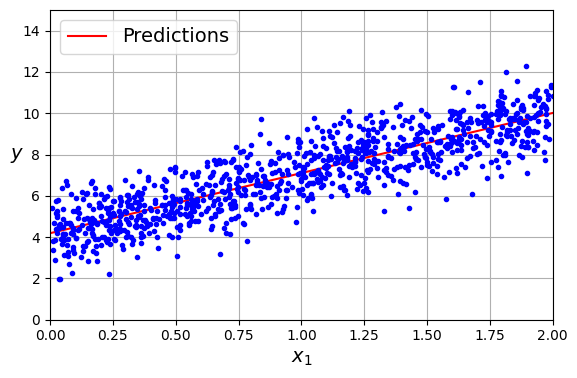

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

# extra code – beautifies and saves plot
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

NB. Het ML model `LinearRegression` is gebaseerd op de functie `scipy.linalg.lstsq()` (de naam staat voor "kleinste kwadraten").

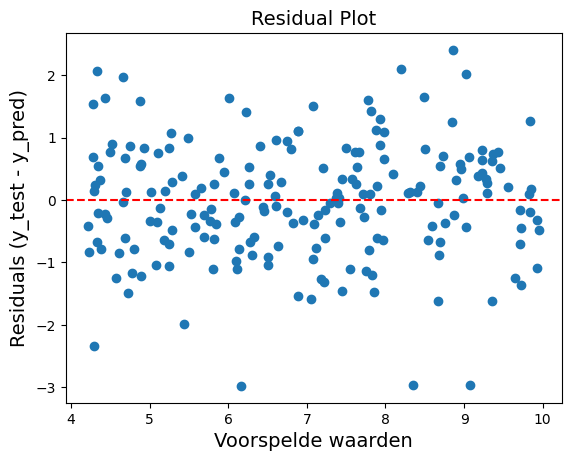

In [28]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



# 3. Voorspellingen
y_pred = lin_reg.predict(X_test)

# 4. Residuals
residuals = y_test - y_pred

# 5. Plot
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Voorspelde waarden")
plt.ylabel("Residuals (y_test - y_pred)")
plt.title("Residual Plot")
plt.show()


---

## Een 2de uitgebreider voorbeeld Linear regression

We nemen nu ook mee een metriek, zoals R<sup>2</sup> om te zien "hoe goed" het model is.

Laten we wat gegevens fabriceren die een ruwweg lineaire relatie laten zien tussen de paginasnelheid (in seconden) en het gekochte bedrag (in euro's):

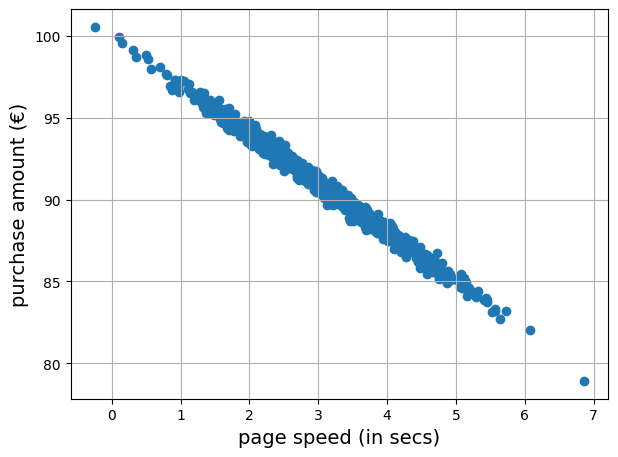

In [7]:
%matplotlib inline

pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = 100 - (pageSpeeds + np.random.normal(0, 0.1, 1000)) * 3

# extra code – nicer plot
plt.xlabel("page speed (in secs)")
plt.ylabel("purchase amount (€)")
plt.grid()

plt.scatter(pageSpeeds, purchaseAmount)

save_fig("Pagespeed-scatterplot")
plt.show()

Omdat we maar twee attributen/features hebben, kunnen we het simpel houden en gebruik maken van `scipy.state.linregress`:

In [8]:
from scipy import stats

slope, intercept, r_value, p_value, std_err  \
= stats.linregress(pageSpeeds, purchaseAmount)

#slope

In [9]:
# ML-model vergelijking
print(f"ML-model: purchaseAmount = {slope:0.3f}*pageSpeed + {intercept:0.3f}")

ML-model: purchaseAmount = -2.987*pageSpeed + 99.952


R<sup>2</sup> is een statische metriek waaraan je kan zien hoe goed de aanpassing is. Zie theorie.

Het zal niet verrassend zijn dat onze R<sup>2</sup>-waarde echt goed past:

In [10]:
r_value ** 2

np.float64(0.9903290786370731)

Laten we de helling (*slope*) en het snijpunt (*intercept*) van de regressie gebruiken om de voorspelde waarden uit te zetten tegen de waargenomen waarden:

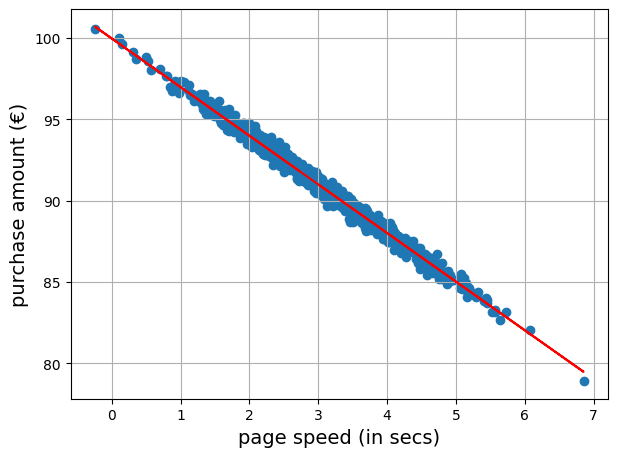

In [11]:
def predict(x):
    return slope * x + intercept

fitLine = predict(pageSpeeds)

# extra code – nicer plot
plt.xlabel("page speed (in secs)")
plt.ylabel("purchase amount (€)")
plt.grid()

plt.scatter(pageSpeeds, purchaseAmount)
plt.plot(pageSpeeds, fitLine, c='r')

save_fig("Pagespeed-linear_model")
plt.show()


## Opdracht linear regression

Probeer de willekeurige variatie in de testgegevens te vergroten en te verkleinen, en kijk welk effect dit heeft op de R<sup>2</sup> waarde.

In [12]:
# hier komt jouw code


# curved residual plot

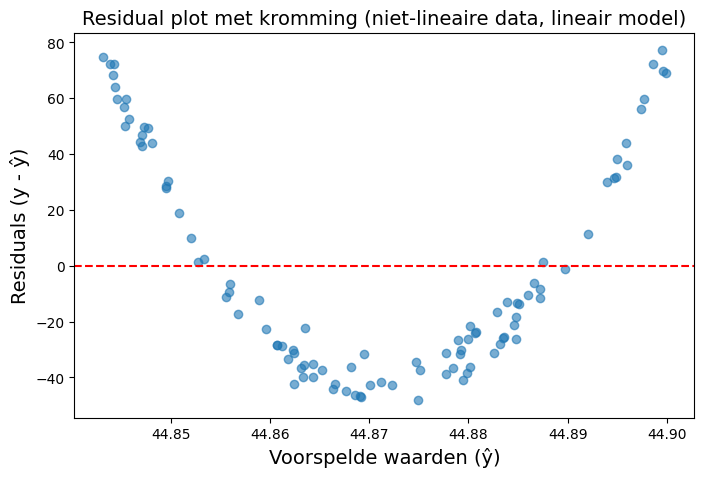

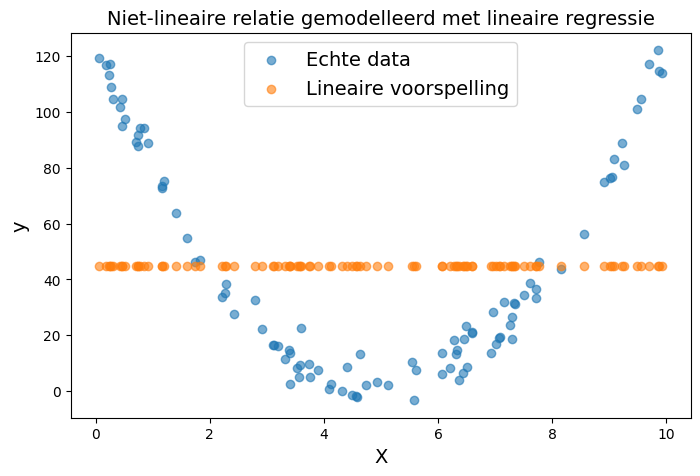

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Data genereren met een NIET-lineaire relatie (parabool)
np.random.seed(42)

# Inputfeature (bijv. pageSpeeds)
X = np.random.uniform(0, 10, 500)  # waarden tussen 0 en 10

# Echte relatie is kwadratisch (gebogen), plus wat ruis
# Bijvoorbeeld: y = 5 * (x - 5)^2 + noise
noise = np.random.normal(0, 5, 500)
y = 5 * (X - 5)**2 + noise

# sklearn wil X als 2D
X = X.reshape(-1, 1)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Lineaire regressie fitten (bewust fout model)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 4. Residuals berekenen
residuals = y_test - y_pred

# 5. Residual plot: hier wil je de kromming zien
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Voorspelde waarden (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residual plot met kromming (niet-lineaire data, lineair model)")
plt.show()

# (optioneel) Ook even de data zelf plotten
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.6, label="Echte data")
plt.scatter(X_test, y_pred, alpha=0.6, label="Lineaire voorspelling")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Niet-lineaire relatie gemodelleerd met lineaire regressie")
plt.legend()
plt.show()


# trechtervorm residual plot

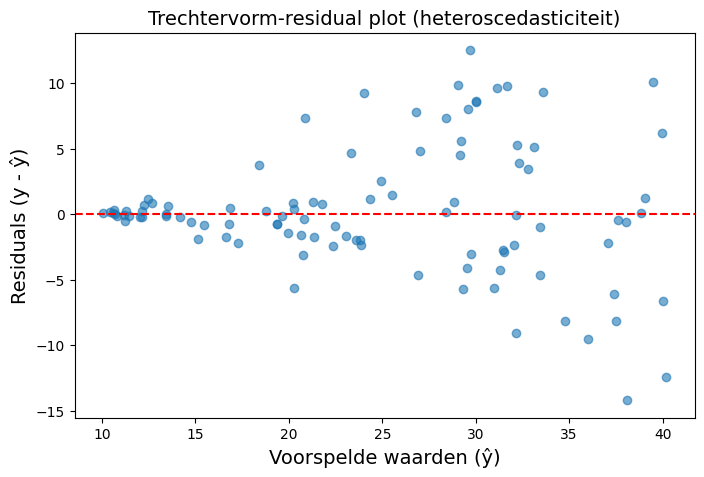

In [30]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# 1. Lineaire relatie
X = np.random.uniform(0, 10, 500)

# 2. Noise die groter wordt als X groter wordt (trechter)
noise = np.random.normal(0, X * 0.8)   # variantie groeit mee met X

# 3. Target y
y = 3 * X + 10 + noise

# sklearn wil X in 2D
X = X.reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Lineair model fitten
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Residual plot met trechter
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Voorspelde waarden (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Trechtervorm-residual plot (heteroscedasticiteit)")
plt.show()


# clustervorming in residuals


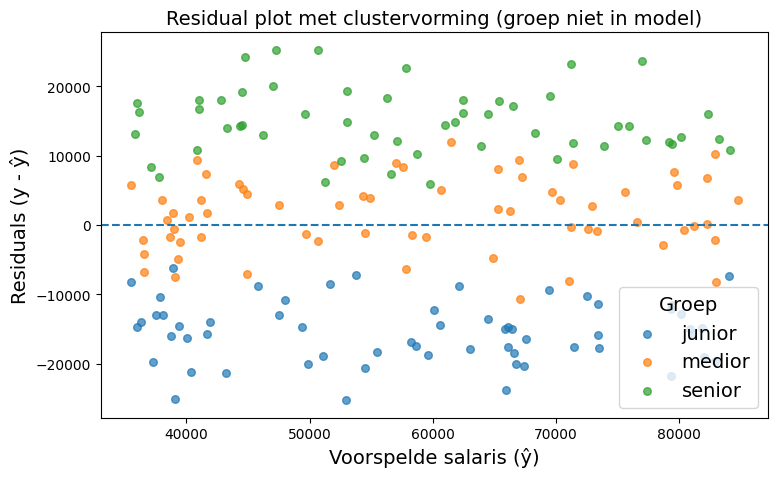

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Reproduceerbaarheid
np.random.seed(42)

# 1. Data genereren met een ontbrekende categorische variabele
n = 600

# Eén numerieke feature, bijv. jaren werkervaring
years_exp = np.random.uniform(0, 20, n)

# Verborgen categorie, bijv. functie: 'junior', 'medior', 'senior'
groups = np.random.choice(['junior', 'medior', 'senior'], size=n, p=[0.3, 0.4, 0.3])

# Verschillende intercepts per groep (zorgt voor clusters!)
group_intercepts = {
    'junior': 20000,
    'medior': 35000,
    'senior': 50000
}

# Zelfde helling voor iedereen (voor de eenvoud)
slope = 2500

# Noise
noise = np.random.normal(0, 5000, n)

# Doelvariabele: salaris
salary = np.array([
    group_intercepts[g] + slope * x + e
    for g, x, e in zip(groups, years_exp, noise)
])

# In een DataFrame (handig als je later nog wilt uitbreiden)
df = pd.DataFrame({
    'years_exp': years_exp,
    'group': groups,
    'salary': salary
})

# 2. Model fitten ZONDER de groep (dit gaat voor clustervorming zorgen)
X = df[['years_exp']]      # we laten 'group' bewust weg
y = df['salary']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, df['group'], test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

# 3. Residual plot met clustervorming
plt.figure(figsize=(8, 5))

# Kleur per verborgen groep, zodat je de clusters ook echt ziet
colors = {'junior': 'tab:blue', 'medior': 'tab:orange', 'senior': 'tab:green'}

for g in colors:
    mask = (groups_test == g)
    plt.scatter(
        y_pred[mask],
        residuals[mask],
        alpha=0.7,
        label=g,
        s=30
    )

plt.axhline(0, linestyle='--')
plt.xlabel("Voorspelde salaris (ŷ)")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residual plot met clustervorming (groep niet in model)")
plt.legend(title="Groep", loc='lower right')
plt.tight_layout()
plt.show()


# (in)significante features

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)

# 1. Data genereren
n = 200

# Echte, relevante features
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)

# Ruis-features (geen echte relatie met y)
X3 = np.random.normal(0, 1, n)
X4 = np.random.normal(0, 1, n)

# Doelvariabele: alleen X1 en X2 zitten echt in het model
# y = 3*X1 - 2*X2 + noise
noise = np.random.normal(0, 1, n)
y = 3*X1 - 2*X2 + noise

# In een DataFrame stoppen
df = pd.DataFrame({
    "X1_relevant": X1,
    "X2_relevant": X2,
    "X3_ruis": X3,
    "X4_ruis": X4,
    "y": y
})

# 2. Model fitten met statsmodels (voor p-waardes)
X = df[["X1_relevant", "X2_relevant", "X3_ruis", "X4_ruis"]]
X = sm.add_constant(X)  # intercept toevoegen

model = sm.OLS(df["y"], X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     618.4
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          1.50e-109
Time:                        13:57:27   Log-Likelihood:                -269.58
No. Observations:                 200   AIC:                             549.2
Df Residuals:                     195   BIC:                             565.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1359      0.067      2.018      

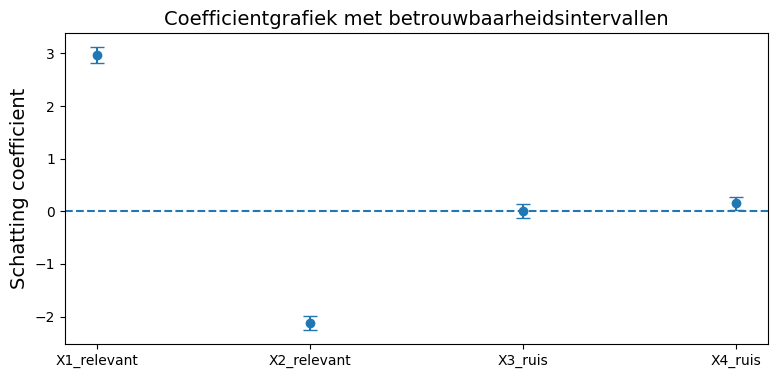

In [35]:
# 3. Coefficientgrafiek (coef plot)

params = model.params
conf_int = model.conf_int()   # betrouwbaarheidsintervallen
features = params.index       # namen (const, X1, X2, ...)

# Voor de grafiek slaan we de constant vaak over
mask = features != "const"

coef = params[mask]
ci_lower = conf_int[0][mask]
ci_upper = conf_int[1][mask]

# Foutmarges = afstand van coef naar onder/ boven CI
yerr = [coef - ci_lower, ci_upper - coef]

plt.figure(figsize=(8, 4))
plt.errorbar(
    x=coef.index,
    y=coef.values,
    yerr=yerr,
    fmt="o",
    capsize=5
)
plt.axhline(0, linestyle="--")
plt.ylabel("Schatting coefficient")
plt.title("Coefficientgrafiek met betrouwbaarheidsintervallen")
plt.tight_layout()
plt.show()
